In [1]:
## set up data

In [2]:
pip install yfinance 

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 236.6 kB/s eta 0:00:05
   ------------ --------------------------- 0.5/1.7 MB 236.6 kB/s eta 0:00:05
   ------------ --------------------------- 0.5/1.7 MB 236.6 kB/s eta 0:00:05
   ------------ --------------------------- 0.5/1.7 MB 236.6 kB/s eta 0:00:0

In [5]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

ticker = 'FWRY.CA'

data= yf.download(ticker, start="2022-01-01", end="2026-06-26")
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,FWRY.CA,FWRY.CA,FWRY.CA,FWRY.CA,FWRY.CA
Date,,,,,
2022-01-02,6.849674,7.087547,6.768581,6.925361,2901122
2022-01-03,6.773987,6.892923,6.730737,6.849674,2631833
2022-01-04,6.892923,7.006454,6.811830,6.773987,3930690
2022-01-05,7.001048,7.098360,6.974017,6.892923,3889638
2022-01-09,7.001048,7.001048,7.001048,7.001048,0


In [6]:
## plot the price trend 

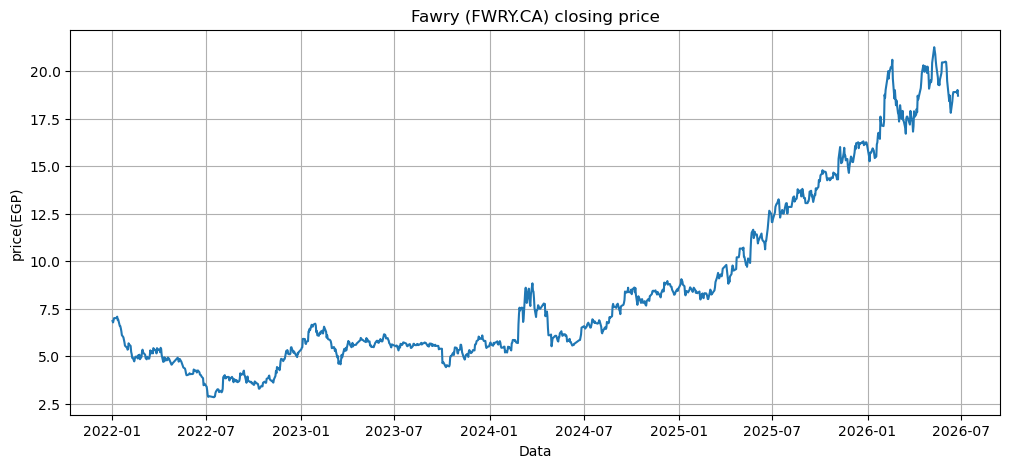

In [10]:
plt.figure(figsize=(12,5))
plt.plot(data.index, data['Close'])
plt.title('Fawry (FWRY.CA) closing price')
plt.xlabel('Data')
plt.ylabel('price(EGP)')
plt.grid(True)
plt.show()

In [11]:
##calculate daily returns and rolling volitalty 

In [19]:
data.columns=data.columns.get_level_values(0)
data['Daily_Return'] = data['Close'].pct_change()
data['Volatility_30d']= data['Daily_Return'].rolling(window=30).std()
data[['Close','Daily_Return', 'Volatility_30d']].tail(10)

Price,Close,Daily_Return,Volatility_30d
Date,,,
2026-06-14,18.400000,0.033708,0.022513
2026-06-15,18.740000,0.018478,0.021831
2026-06-16,18.889999,0.008004,0.021444
2026-06-17,18.889999,0.000000,0.021429
2026-06-18,18.889999,0.000000,0.021371
2026-06-21,18.900000,0.000529,0.019581
2026-06-22,18.900000,0.000000,0.017871
2026-06-23,18.850000,-0.002645,0.017854
2026-06-24,19.000000,0.007958,0.017938


In [20]:
##plot volatility 

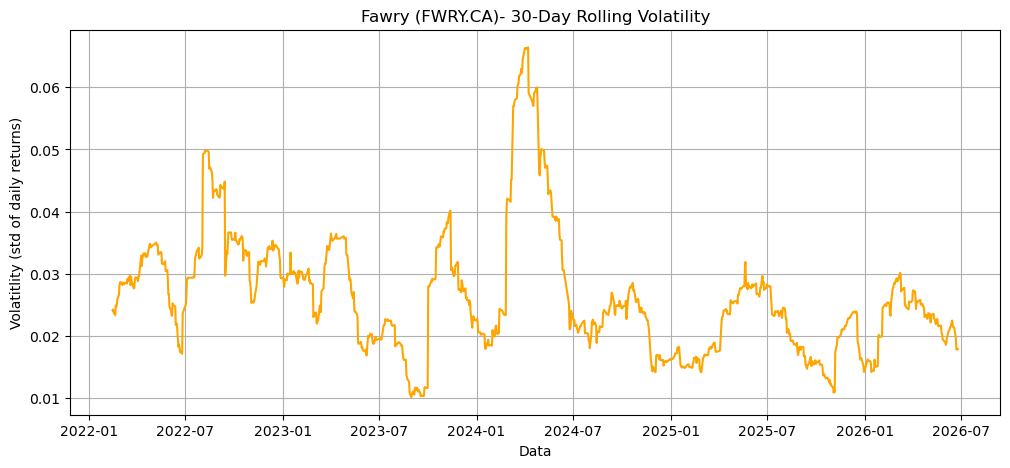

In [22]:
plt.figure(figsize=(12,5))
plt.plot(data.index, data['Volatility_30d'],color='orange')
plt.title('Fawry (FWRY.CA)- 30-Day Rolling Volatility')
plt.xlabel('Data')
plt.ylabel('Volatitlity (std of daily returns)')
plt.grid(True)
plt.show()

In [23]:
events = pd.DataFrame([
    {"date": "2023-12-21", "event": "Fawry partners with POS Mission for restaurant management", "sentiment": "positive"},
    {"date": "2023-12-28", "event": "Fawry partners with Simple Touch (F&B digital payments)", "sentiment": "positive"},
    {"date": "2024-02-26", "event": "Fawry teams up with LA Market for digital transformation", "sentiment": "positive"},
    {"date": "2024-05-01", "event": "CEO transition: founder steps down, Dennis Woodside becomes CEO", "sentiment": "neutral"},
    {"date": "2024-08-15", "event": "H1-24 net profit up 111% YoY", "sentiment": "positive"},
    {"date": "2024-09-11", "event": "Fawry acquires 80% of Svreico admin building", "sentiment": "neutral"},
    {"date": "2024-11-18", "event": "9M-24 profits up 127%, revenue up 66%", "sentiment": "positive"},
    {"date": "2024-12-04", "event": "Fawry's BNPL transactions cross EGP 2bn", "sentiment": "positive"},
    {"date": "2025-03-02", "event": "FY2024 results: revenue +68%, net profit +125%", "sentiment": "positive"},
    {"date": "2025-08-17", "event": "H1-25 net profit up ~100% YoY", "sentiment": "positive"},
    {"date": "2025-09-09", "event": "Fawry partners with CDS Solutions (POS-Odoo integration)", "sentiment": "positive"},
    {"date": "2025-11-18", "event": "9M-25 profits up 84% YoY", "sentiment": "positive"},
    {"date": "2026-02-01", "event": "CBE launches Soft POS service nationally", "sentiment": "positive"},
    {"date": "2026-03-05", "event": "FY2025 results: revenue +57%, net profit +80%", "sentiment": "positive"},
])
events['date'] = pd.to_datetime(events['date'])
events

,date,event,sentiment
0,2023-12-21,Fawry partners with POS Mission for restaurant...,positive
1,2023-12-28,Fawry partners with Simple Touch (F&B digital ...,positive
2,2024-02-26,Fawry teams up with LA Market for digital tran...,positive
3,2024-05-01,"CEO transition: founder steps down, Dennis Woo...",neutral
4,2024-08-15,H1-24 net profit up 111% YoY,positive
5,2024-09-11,Fawry acquires 80% of Svreico admin building,neutral
6,2024-11-18,"9M-24 profits up 127%, revenue up 66%",positive
7,2024-12-04,Fawry's BNPL transactions cross EGP 2bn,positive
8,2025-03-02,"FY2024 results: revenue +68%, net profit +125%",positive
9,2025-08-17,H1-25 net profit up ~100% YoY,positive


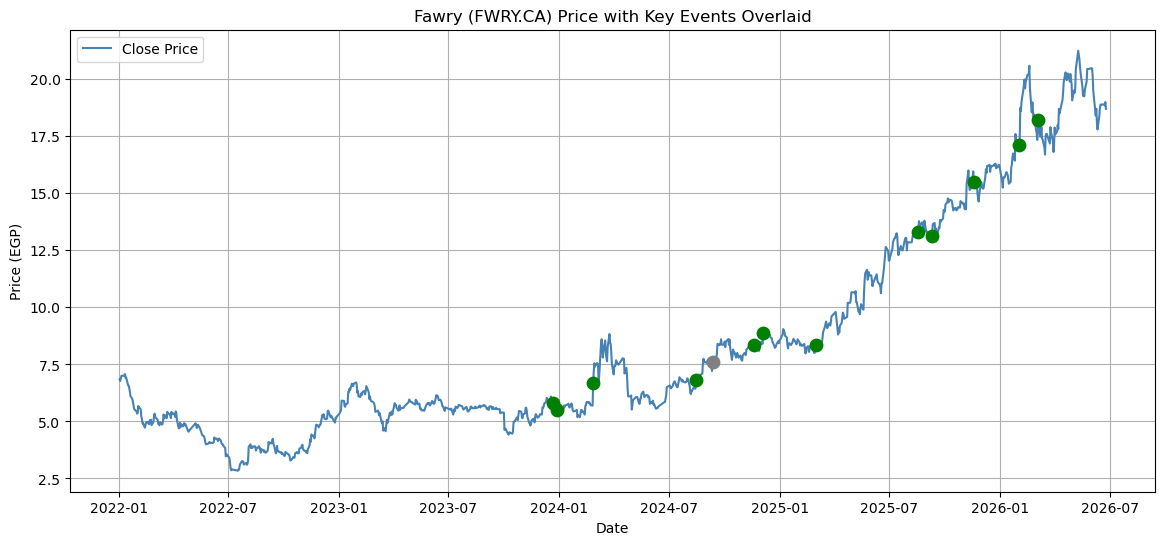

In [24]:
plt.figure(figsize=(14,6))
plt.plot(data.index, data['Close'], label='Close Price', color='steelblue')

colors = {'positive': 'green', 'negative': 'red', 'neutral': 'gray'}

for _, row in events.iterrows():
    if row['date'] in data.index:
        price_at_event = data.loc[row['date'], 'Close']
        plt.scatter(row['date'], price_at_event, color=colors[row['sentiment']], s=80, zorder=5)

plt.title('Fawry (FWRY.CA) Price with Key Events Overlaid')
plt.xlabel('Date')
plt.ylabel('Price (EGP)')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
missing_dates = [d for d in events['date'] if d not in data.index]
print(missing_dates)

[Timestamp('2024-05-01 00:00:00')]


In [26]:
def nearest_trading_day(date, index):
    if date in index:
        return date
    # find nearest date in index
    diffs = abs(index - date)
    return index[diffs.argmin()]

events['date'] = events['date'].apply(lambda d: nearest_trading_day(d, data.index))

# re-check
missing_dates = [d for d in events['date'] if d not in data.index]
print(missing_dates)

[]


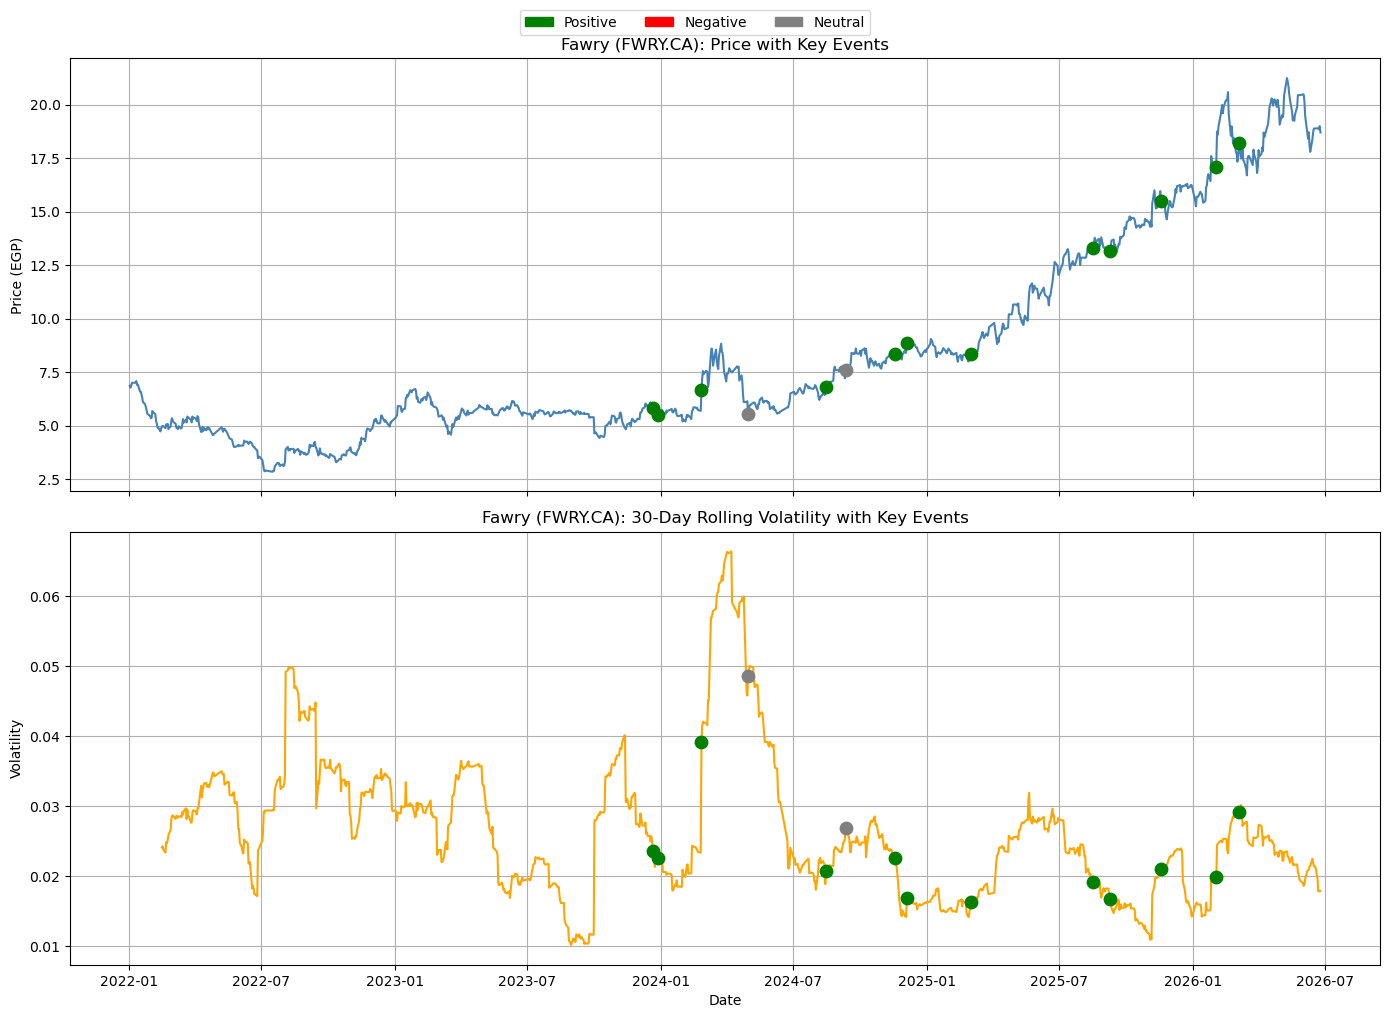

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

colors = {'positive': 'green', 'negative': 'red', 'neutral': 'gray'}

# --- Panel 1: Price with events ---
axes[0].plot(data.index, data['Close'], label='Close Price', color='steelblue')
for _, row in events.iterrows():
    price_at_event = data.loc[row['date'], 'Close']
    axes[0].scatter(row['date'], price_at_event, color=colors[row['sentiment']], s=80, zorder=5)
axes[0].set_title('Fawry (FWRY.CA): Price with Key Events')
axes[0].set_ylabel('Price (EGP)')
axes[0].grid(True)

# --- Panel 2: Volatility with events ---
axes[1].plot(data.index, data['Volatility_30d'], color='orange', label='30-Day Volatility')
for _, row in events.iterrows():
    if pd.notna(data.loc[row['date'], 'Volatility_30d']):
        vol_at_event = data.loc[row['date'], 'Volatility_30d']
        axes[1].scatter(row['date'], vol_at_event, color=colors[row['sentiment']], s=80, zorder=5)
axes[1].set_title('Fawry (FWRY.CA): 30-Day Rolling Volatility with Key Events')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Volatility')
axes[1].grid(True)

# --- Legend (shared) ---
import matplotlib.patches as mpatches
legend_handles = [mpatches.Patch(color=c, label=s.capitalize()) for s, c in colors.items()]
fig.legend(handles=legend_handles, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.savefig('fawry_sentiment_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()